
### Langkah 1: Memuat Dataset
Pada langkah pertama, kita akan memuat dataset dummy yang berisi informasi produk dari UMKM, yang mencakup ID produk, nama produk, kategori produk, harga, deskripsi, dan stok yang tersedia.
Dataset ini akan digunakan untuk mengembangkan model klasifikasi produk yang dapat digunakan untuk mengelompokkan produk-produk UMKM berdasarkan fitur dan deskripsi mereka.


In [ ]:

import pandas as pd
import numpy as np

# Load the dataset
dummy_df = pd.read_excel('12_klasifikasi_produk_e-commerce.xlsx')
dummy_df


,Product ID,Product Name,Category,Price (IDR),Description,Stock
0,1,Product D,Electronics,994853.168710,Eco-friendly,40
1,2,Product E,Fashion,373200.158897,High quality,240
2,3,Product D,Fashion,828628.648180,Durable,117
3,4,Product A,Food & Beverage,541602.301473,Luxury,458
4,5,Product C,Fashion,584398.890738,Luxury,391
...,...,...,...,...,...,...
95,96,Product A,Home & Living,870435.974029,Affordable,639
96,97,Product D,Home & Living,346014.245692,Luxury,990
97,98,Product E,Home & Living,541912.241875,High quality,958
98,99,Product E,Electronics,790972.186056,Durable,546



### Langkah 2: Visualisasi Data
Pada langkah kedua, kita akan memvisualisasikan beberapa distribusi data. Pertama, kita akan melihat distribusi harga produk dengan histogram. Kemudian, kita akan melihat jumlah produk berdasarkan kategori untuk melihat sebaran kategori produk yang ada.
Visualisasi ini membantu kita memahami distribusi data yang ada dalam dataset produk UMKM.


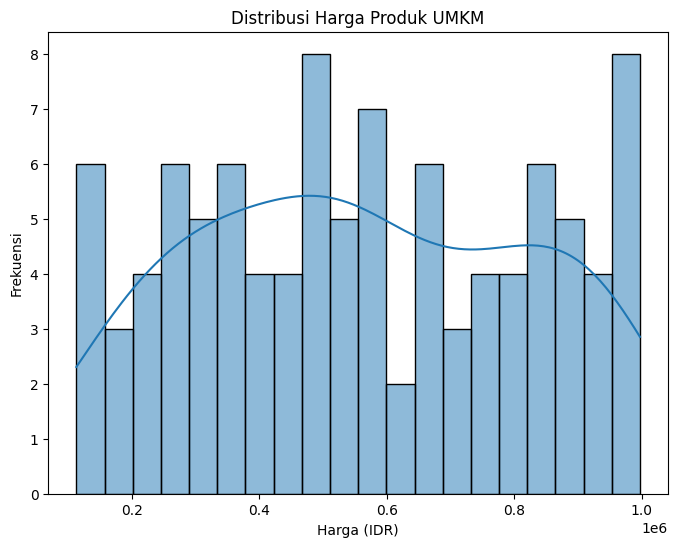

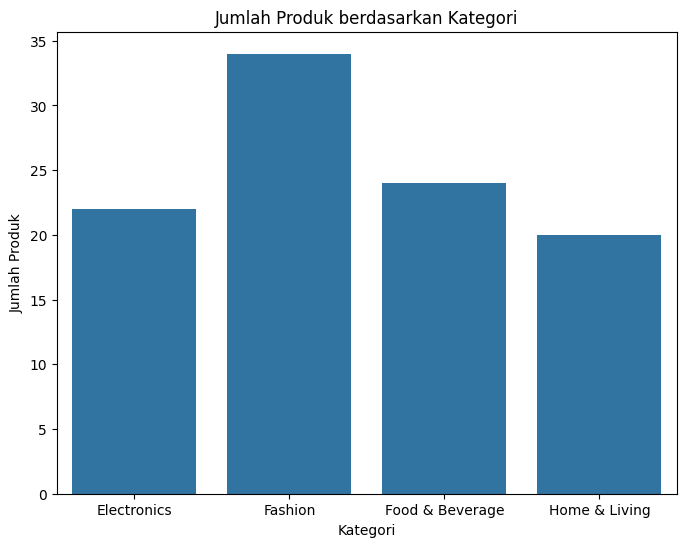

In [ ]:

# Langkah 2: Visualisasi Data
import matplotlib.pyplot as plt
import seaborn as sns

# Visualisasi distribusi harga produk
plt.figure(figsize=(8, 6))
sns.histplot(dummy_df['Price (IDR)'], bins=20, kde=True)
plt.title('Distribusi Harga Produk UMKM')
plt.xlabel('Harga (IDR)')
plt.ylabel('Frekuensi')
plt.show()

# Visualisasi jumlah produk berdasarkan kategori
plt.figure(figsize=(8, 6))
sns.countplot(x='Category', data=dummy_df)
plt.title('Jumlah Produk berdasarkan Kategori')
plt.xlabel('Kategori')
plt.ylabel('Jumlah Produk')
plt.show()



### Langkah 3: Preprocessing Data
Pada langkah ini, kita akan memproses data dengan melakukan enkoding pada variabel kategori dan deskripsi produk menggunakan LabelEncoder dari scikit-learn. Hal ini diperlukan karena model pembelajaran mesin membutuhkan data dalam bentuk numerik untuk dapat melakukan analisis dan prediksi.


In [ ]:

# Langkah 3: Preprocessing Data
from sklearn.preprocessing import LabelEncoder

# Mengencode kategori produk dan deskripsi
label_encoder = LabelEncoder()
dummy_df['Category'] = label_encoder.fit_transform(dummy_df['Category'])
dummy_df['Description'] = label_encoder.fit_transform(dummy_df['Description'])

# Memeriksa data setelah preprocessing
dummy_df.head()


,Product ID,Product Name,Category,Price (IDR),Description,Stock
0,1,Product D,0,994853.168710,2,40
1,2,Product E,1,373200.158897,3,240
2,3,Product D,1,828628.648180,1,117
3,4,Product A,2,541602.301473,4,458
4,5,Product C,1,584398.890738,4,391



### Langkah 4: Normalisasi Data
Pada langkah ini, kita akan melakukan normalisasi pada data numerik seperti harga dan stok produk agar berada pada skala yang sama. Normalisasi ini penting untuk meningkatkan kinerja model pembelajaran mesin, terutama pada model yang sensitif terhadap skala data.


In [ ]:

# Langkah 4: Normalisasi Data
from sklearn.preprocessing import StandardScaler

# Melakukan normalisasi pada kolom harga dan stok produk
scaler = StandardScaler()
dummy_df[['Price (IDR)', 'Stock']] = scaler.fit_transform(dummy_df[['Price (IDR)', 'Stock']])

# Memeriksa data setelah normalisasi
dummy_df.head()


,Product ID,Product Name,Category,Price (IDR),Description,Stock
0,1,Product D,0,1.671748,2,-1.632445
1,2,Product E,1,-0.732219,3,-0.926400
2,3,Product D,1,1.028949,1,-1.360618
3,4,Product A,2,-0.080998,4,-0.156812
4,5,Product C,1,0.084499,4,-0.393337



### Langkah 5: Membagi Data Train dan Test
Pada langkah ini, kita akan membagi dataset menjadi data latih (train) dan data uji (test) dengan proporsi 80% untuk latih dan 20% untuk uji. Hal ini penting agar kita dapat melatih model menggunakan data latih dan mengujinya dengan data yang tidak terlihat sebelumnya.


In [ ]:

# Langkah 5: Membagi Data Train dan Test
from sklearn.model_selection import train_test_split

# Memisahkan data menjadi fitur (X) dan target (y)
X = dummy_df[['Category', 'Price (IDR)', 'Stock', 'Description']]
y = dummy_df['Product Name']

# Membagi data menjadi data latih (train) dan data uji (test) dengan proporsi 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Menampilkan ukuran data train dan test
(X_train.shape, X_test.shape)


((80, 4), (20, 4))


### Langkah 6: Melatih Model
Pada langkah ini, kita akan menggunakan algoritma Random Forest untuk melatih model klasifikasi produk. Random Forest merupakan model ensemble yang kuat dan sering digunakan untuk masalah klasifikasi dengan berbagai fitur. Kita juga akan melihat pentingnya fitur berdasarkan model yang telah dilatih.


In [ ]:

# Langkah 6: Melatih Model
from sklearn.ensemble import RandomForestClassifier

# Membuat dan melatih model RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Melihat fitur penting dari model
model.feature_importances_


array([0.11572857, 0.38031028, 0.35774454, 0.14621661])


### Langkah 7: Evaluasi Model
Pada langkah ini, kita akan mengevaluasi kinerja model dengan menggunakan data uji. Kita akan menghitung akurasi dan menampilkan laporan klasifikasi untuk melihat performa model pada kategori produk yang berbeda.


In [ ]:

# Langkah 7: Evaluasi Model
from sklearn.metrics import accuracy_score, classification_report

# Memprediksi hasil pada data uji
y_pred = model.predict(X_test)

# Menghitung akurasi dan menampilkan laporan klasifikasi
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

accuracy, report


(0.25,
 '              precision    recall  f1-score   support\n\n   Product A       0.00      0.00      0.00         4\n   Product B       0.14      0.50      0.22         2\n   Product C       0.60      0.43      0.50         7\n   Product D       0.33      0.33      0.33         3\n   Product E       0.00      0.00      0.00         4\n\n    accuracy                           0.25        20\n   macro avg       0.22      0.25      0.21        20\nweighted avg       0.27      0.25      0.25        20\n')


### Langkah 8: Prediksi
Pada langkah terakhir, kita akan menggunakan model yang telah dilatih untuk memprediksi nama produk berdasarkan data baru. Dengan demikian, model dapat digunakan untuk mengklasifikasikan produk-produk baru yang akan ditambahkan ke dalam platform e-commerce.


In [ ]:
# Now, you can transform and it will find the new category.
new_data = pd.DataFrame({
    'Category': [label_encoder.transform(['Fashion'])[0]],
    'Price (IDR)': [500000], #Keep as original value
    'Stock': [50], #Keep as original value
    'Description': [label_encoder.transform(['Affordable'])[0]]  # Assuming 'Affordable' was a known description in training data
})

# Scale both 'Price (IDR)' and 'Stock' at the same time:
new_data[['Price (IDR)', 'Stock']] = scaler.transform(new_data[['Price (IDR)', 'Stock']])

# Memprediksi nama produk untuk data baru
prediction = model.predict(new_data)
prediction

array(['Product A'], dtype=object)


## Keterangan Penting

Notebook ini menggunakan data dummy. Agar model ini dapat menghasilkan prediksi yang lebih akurat dan relevan, **kustomisasi lebih lanjut diperlukan**. Beberapa hal yang perlu dipertimbangkan antara lain:

1. **Penyempurnaan Dataset**: Data yang digunakan adalah data dummy yang bersifat acak. Untuk hasil yang lebih baik, dataset harus diisi dengan data kemacetan lalu lintas yang lebih realistis dan sesuai dengan kondisi lokal yang relevan.
   
2. **Penyesuaian Fitur**: Beberapa fitur, seperti jumlah kendaraan, kecepatan rata-rata, atau status sinyal lalu lintas, perlu penyesuaian atau penambahan fitur lain yang lebih berdampak pada prediksi kemacetan.

3. **Parameter Model**: Untuk hasil prediksi yang lebih optimal, Anda dapat menyesuaikan parameter model SVM atau mencoba model lain yang lebih sesuai dengan karakteristik data.

4. **Validasi Model**: Melakukan validasi dengan data nyata dan cross-validation untuk mengevaluasi kinerja model.

Dengan penyesuaian yang tepat, model ini dapat memberikan prediksi kemacetan yang lebih akurat dan bermanfaat untuk mengatur lalu lintas di kota dan meningkatkan mobilitas perkotaan.
